# Unit 05｜公平基准协议

## Goal

先多种子比较材料发现的 Random/Greedy/UCB/EI，再比较全局模型学习的 Random/Uncertainty。

本 Notebook 是确定性的人工教学实验，不是学习者已完成的研究，
也不是下游任务实验结果。


## Setup

本教程使用固定核 GP 和 8 个预声明种子，分别报告 simple regret 与固定测试集 RMSE。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

def synthetic_objective(x):
    x = np.asarray(x, dtype=float)
    return (
        np.sin(0.8 * x)
        + 0.25 * np.cos(2.4 * x)
        + 0.04 * x
    )

X_all = np.linspace(0.0, 14.0, 51).reshape(-1, 1)
oracle_values = synthetic_objective(X_all[:, 0])
candidate_ids = np.array([f"D{i:02d}" for i in range(len(X_all))])

def discovery_oracle(global_indices):
    indices = np.atleast_1d(global_indices).astype(int)
    values = oracle_values[indices].copy()
    return float(values[0]) if np.isscalar(global_indices) else values

run_seeds = [11, 22, 33, 44, 55, 66, 77, 88]
print("候选数:", len(X_all), "种子数:", len(run_seeds))


候选数: 51 种子数: 8


## Steps

按顺序执行。每个变量第一次出现时，先确认它的类型、形状和标签权限。


### 1. 定义模型与 EI

固定 GP 规格；EI 的当前最好值只来自已标注集。


In [2]:
def make_gp():
    kernel = (
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RBF(0.9, length_scale_bounds="fixed")
        + WhiteKernel(0.02, noise_level_bounds="fixed")
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=True,
    )

def expected_improvement(mean, std, best_observed, xi=0.01):
    safe_std = np.maximum(std, 1e-12)
    improvement = mean - best_observed - xi
    z = improvement / safe_std
    ei = improvement * norm.cdf(z) + std * norm.pdf(z)
    return np.where(
        std > 0,
        ei,
        np.maximum(improvement, 0.0),
    )

def select_with_tie_break(score, ids):
    order = np.lexsort((ids.astype(str), -np.asarray(score)))
    return int(order[0])


### 2. 运行一个策略

策略只接收初始标签和 Oracle 回调；记录第 0 轮及协议要求的全部 query 字段。


In [3]:
def run_strategy(
    strategy,
    initial_indices,
    initial_values,
    run_seed,
    oracle,
    n_rounds=8,
):
    labeled = list(np.array(initial_indices, dtype=int))
    labeled_y = list(np.asarray(initial_values, dtype=float))
    pool = [
        index for index in range(len(X_all))
        if index not in labeled
    ]
    rng = np.random.default_rng(run_seed + 1000)
    records = [{
        "event": "initial_state",
        "strategy": strategy,
        "run_seed": run_seed,
        "round": 0,
        "candidate_id": None,
        "prediction_mean": np.nan,
        "prediction_std": np.nan,
        "acquisition_score": np.nan,
        "observed_y": np.nan,
        "n_labeled": len(labeled),
        "best_so_far": float(np.max(labeled_y)),
        "model_version": "fixed_gp_rbf_v1",
    }]

    for round_number in range(1, n_rounds + 1):
        model = make_gp()
        model.fit(X_all[labeled], np.asarray(labeled_y))
        mean, std = model.predict(X_all[pool], return_std=True)

        if strategy == "random":
            score = np.full(len(pool), np.nan)
            query_local = int(rng.integers(len(pool)))
        elif strategy == "greedy":
            score = mean
            query_local = select_with_tie_break(
                score,
                candidate_ids[pool],
            )
        elif strategy == "ucb":
            score = mean + 1.2 * std
            query_local = select_with_tie_break(
                score,
                candidate_ids[pool],
            )
        elif strategy == "ei":
            best_observed = float(np.max(labeled_y))
            score = expected_improvement(mean, std, best_observed)
            query_local = select_with_tie_break(
                score,
                candidate_ids[pool],
            )
        else:
            raise ValueError(strategy)

        query_global = int(pool[query_local])
        record = {
            "event": "query",
            "strategy": strategy,
            "run_seed": run_seed,
            "round": round_number,
            "candidate_id": candidate_ids[query_global],
            "prediction_mean": float(mean[query_local]),
            "prediction_std": float(std[query_local]),
            "acquisition_score": (
                float(score[query_local])
                if strategy != "random"
                else np.nan
            ),
            "model_version": "fixed_gp_rbf_v1",
        }

        # 标签揭示线
        observed_y = float(oracle(query_global))
        labeled.append(query_global)
        labeled_y.append(observed_y)
        pool.remove(query_global)
        best_so_far = float(np.max(labeled_y))
        record.update({
            "observed_y": observed_y,
            "n_labeled": len(labeled),
            "best_so_far": best_so_far,
        })
        records.append(record)
    return records


### 3. 建立共享初始集并运行实验矩阵

每个种子的四种策略共享同一初始集；全部 campaign 完成后 evaluator 才计算全局最优与 regret。


In [4]:
records = []
initial_sets = {}
for run_seed in run_seeds:
    initial_rng = np.random.default_rng(run_seed)
    initial = initial_rng.choice(
        len(X_all), size=4, replace=False
    )
    initial_sets[run_seed] = tuple(sorted(initial.tolist()))
    initial_values = discovery_oracle(initial)
    for strategy in ("random", "greedy", "ucb", "ei"):
        records.extend(
            run_strategy(
                strategy,
                initial_indices=initial.copy(),
                initial_values=initial_values.copy(),
                run_seed=run_seed,
                oracle=discovery_oracle,
            )
        )

runs = pd.DataFrame(records)
offline_global_best = float(oracle_values.max())
runs["simple_regret"] = (
    offline_global_best - runs["best_so_far"]
)
print(runs.head(9).round(4).to_string(index=False))


        event strategy  run_seed  round candidate_id  prediction_mean  prediction_std  acquisition_score  observed_y  n_labeled  best_so_far   model_version  simple_regret
initial_state   random        11      0         None              NaN             NaN                NaN         NaN          4       1.1913 fixed_gp_rbf_v1         0.3714
        query   random        11      1          D14           0.3578          0.7203                NaN     -0.0876          5       1.1913 fixed_gp_rbf_v1         0.3714
        query   random        11      2          D15          -0.0832          0.2378                NaN     -0.2469          6       1.1913 fixed_gp_rbf_v1         0.3714
        query   random        11      3          D03           0.6145          0.4919                NaN      0.5485          7       1.1913 fixed_gp_rbf_v1         0.3714
        query   random        11      4          D29          -0.0781          0.5397                NaN      0.7368          8       1.1913

### 4. 汇总均值和标准差

长表保留原始轨迹，汇总表用于阅读。


In [5]:
summary = runs.groupby(
    ["strategy", "round"], as_index=False
).agg(
    regret_mean=("simple_regret", "mean"),
    regret_std=("simple_regret", "std"),
    n_runs=("run_seed", "nunique"),
)
final_summary = summary[summary["round"] == 8]
print(final_summary.round(4).to_string(index=False))


strategy  round  regret_mean  regret_std  n_runs
      ei      8       0.0000      0.0000       8
  greedy      8       0.0043      0.0121       8
  random      8       0.2199      0.2528       8
     ucb      8       0.0000      0.0000       8


### 5. 增加全局模型学习基准

Uncertainty 以降低固定测试集 RMSE 为目标；测试标签只由 evaluator 读取，不参与选样。


In [6]:
X_model_pool = np.linspace(0.0, 14.0, 51).reshape(-1, 1)
model_pool_values = synthetic_objective(X_model_pool[:, 0])
model_candidate_ids = np.array([
    f"L{i:02d}" for i in range(len(X_model_pool))
])
X_fixed_test = np.linspace(0.07, 13.93, 80).reshape(-1, 1)
y_fixed_test = synthetic_objective(X_fixed_test[:, 0])

def model_learning_oracle(global_indices):
    indices = np.atleast_1d(global_indices).astype(int)
    values = model_pool_values[indices].copy()
    return (
        float(values[0])
        if np.isscalar(global_indices)
        else values
    )

def evaluate_fixed_test(model):
    prediction = model.predict(X_fixed_test)
    return float(np.sqrt(np.mean(
        (y_fixed_test - prediction) ** 2
    )))

def run_model_learning(
    strategy,
    initial_indices,
    initial_values,
    run_seed,
    oracle,
    evaluator,
    n_rounds=8,
):
    labeled = list(np.asarray(initial_indices, dtype=int))
    labeled_y = list(np.asarray(initial_values, dtype=float))
    pool = [
        index for index in range(len(X_model_pool))
        if index not in labeled
    ]
    rng = np.random.default_rng(run_seed + 2000)
    metric_records = []
    query_records = []

    for round_number in range(n_rounds + 1):
        model = make_gp()
        model.fit(
            X_model_pool[labeled],
            np.asarray(labeled_y),
        )
        metric_records.append({
            "strategy": strategy,
            "run_seed": run_seed,
            "round": round_number,
            "n_labeled": len(labeled),
            "test_rmse": evaluator(model),
            "model_version": "fixed_gp_rbf_v1",
        })
        if round_number == n_rounds:
            break

        mean, std = model.predict(
            X_model_pool[pool],
            return_std=True,
        )
        if strategy == "random":
            score = np.full(len(pool), np.nan)
            query_local = int(rng.integers(len(pool)))
        elif strategy == "uncertainty":
            score = std
            query_local = select_with_tie_break(
                score,
                model_candidate_ids[pool],
            )
        else:
            raise ValueError(strategy)

        query_global = int(pool[query_local])
        query_record = {
            "strategy": strategy,
            "run_seed": run_seed,
            "round": round_number + 1,
            "candidate_id": model_candidate_ids[query_global],
            "prediction_mean": float(mean[query_local]),
            "prediction_std": float(std[query_local]),
            "acquisition_score": (
                float(score[query_local])
                if strategy != "random"
                else np.nan
            ),
            "model_version": "fixed_gp_rbf_v1",
        }
        observed_y = float(oracle(query_global))
        query_record["observed_y"] = observed_y
        query_records.append(query_record)
        labeled.append(query_global)
        labeled_y.append(observed_y)
        pool.remove(query_global)

    return metric_records, query_records

model_metric_records = []
model_query_records = []
for run_seed in run_seeds:
    initial_rng = np.random.default_rng(run_seed)
    initial = initial_rng.choice(
        len(X_model_pool), size=4, replace=False
    )
    initial_values = model_learning_oracle(initial)
    for strategy in ("random", "uncertainty"):
        metric_rows, query_rows = run_model_learning(
            strategy,
            initial.copy(),
            initial_values.copy(),
            run_seed,
            model_learning_oracle,
            evaluate_fixed_test,
        )
        model_metric_records.extend(metric_rows)
        model_query_records.extend(query_rows)

model_learning_metrics = pd.DataFrame(model_metric_records)
model_learning_queries = pd.DataFrame(model_query_records)
model_learning_summary = model_learning_metrics.groupby(
    ["strategy", "round"], as_index=False
).agg(
    rmse_mean=("test_rmse", "mean"),
    rmse_std=("test_rmse", "std"),
    n_runs=("run_seed", "nunique"),
)
print(
    model_learning_summary[
        model_learning_summary["round"] == 8
    ].round(4).to_string(index=False)
)


   strategy  round  rmse_mean  rmse_std  n_runs
     random      8     0.3275     0.118       8
uncertainty      8     0.1317     0.044       8


### 6. 画两类多种子学习曲线

左图回答找最优材料，右图回答提升全局预测；误差带都是跨运行标准差，不是显著性检验。


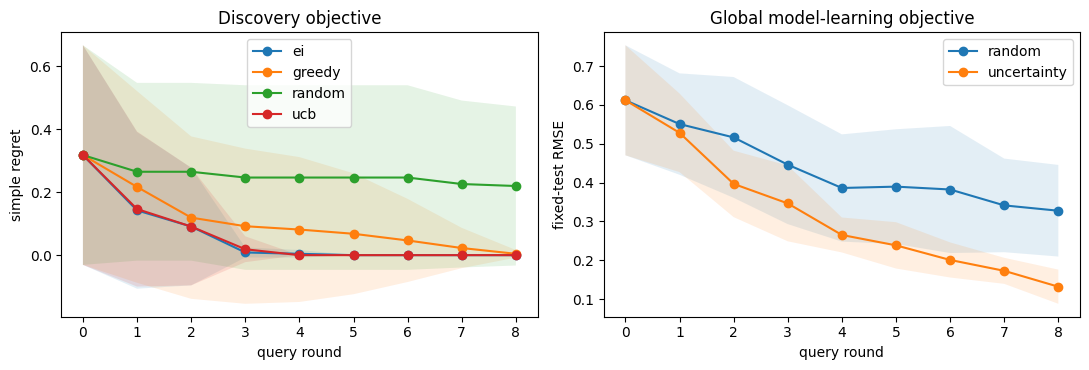

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for strategy, frame in summary.groupby("strategy"):
    x = frame["round"].to_numpy()
    y = frame["regret_mean"].to_numpy()
    spread = frame["regret_std"].fillna(0).to_numpy()
    axes[0].plot(x, y, marker="o", label=strategy)
    axes[0].fill_between(
        x, y - spread, y + spread, alpha=0.12
    )
axes[0].set_xlabel("query round")
axes[0].set_ylabel("simple regret")
axes[0].set_title("Discovery objective")
axes[0].legend()

for strategy, frame in model_learning_summary.groupby("strategy"):
    x = frame["round"].to_numpy()
    y = frame["rmse_mean"].to_numpy()
    spread = frame["rmse_std"].fillna(0).to_numpy()
    axes[1].plot(x, y, marker="o", label=strategy)
    axes[1].fill_between(
        x, y - spread, y + spread, alpha=0.12
    )
axes[1].set_xlabel("query round")
axes[1].set_ylabel("fixed-test RMSE")
axes[1].set_title("Global model-learning objective")
axes[1].legend()
plt.tight_layout()
plt.show()


## Checks

这些断言检查形状、预算和无重复等机械条件；通过断言不代表研究结论已经成立。


In [8]:
assert len(runs) == 8 * 4 * 9
assert summary["n_runs"].eq(8).all()
assert runs.groupby(["strategy", "run_seed"])["n_labeled"].max().eq(12).all()
query_rows = runs[runs["event"] == "query"]
required_query_fields = [
    "candidate_id",
    "prediction_mean",
    "prediction_std",
    "observed_y",
    "model_version",
]
assert query_rows[required_query_fields].notna().all().all()
assert query_rows.groupby(
    ["strategy", "run_seed"]
)["candidate_id"].nunique().eq(8).all()
for run_seed in run_seeds:
    round_zero = runs[(runs["run_seed"] == run_seed) & (runs["round"] == 0)]
    assert round_zero["best_so_far"].nunique() == 1
assert (runs["simple_regret"] >= -1e-12).all()
assert len(model_learning_metrics) == 8 * 2 * 9
assert len(model_learning_queries) == 8 * 2 * 8
assert model_learning_summary["n_runs"].eq(8).all()
assert model_learning_queries[
    required_query_fields
].notna().all().all()
for run_seed in run_seeds:
    round_zero = model_learning_metrics[
        (model_learning_metrics["run_seed"] == run_seed)
        & (model_learning_metrics["round"] == 0)
    ]
    assert round_zero["test_rmse"].nunique() == 1
print("Unit 05 checks passed.")


Unit 05 checks passed.


## Next Steps

保存个人长表并写谨慎结论。Unit 06 会在同一选样思想上加入批量、多样性和可行性。
